# Supply Chain Late Delivery Risk — Model Training (Improved)

**Improvements over v1:**
- `delivery_delay` feature restored (was computed but silently dropped)
- Fixed `profit_margin` division to handle zero-sales rows explicitly
- Added `RandomizedSearchCV` for hyperparameter tuning
- SHAP-based feature importance (named features, not f0/f1/f2...)
- Precision-Recall curve for threshold tuning
- Cleaner, production-ready structure throughout

In [1]:
!pip install xgboost shap

In [2]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from xgboost import XGBClassifier

## 1. Load Dataset

In [3]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")
print(f"Dataset shape: {df.shape}")
df.head(3)

Dataset shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


## 2. Feature Engineering

**Fix:** `profit_margin` now uses `np.where` to handle zero-sales rows explicitly instead of the `+1` distortion hack.  
**Restored:** `delivery_delay` is now included as a feature (it was computed but then excluded in v1).

In [4]:
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'])
df['ship_date']  = pd.to_datetime(df['shipping date (DateOrders)'])

# Restored: delivery_delay was computed but not used in v1
df['delivery_delay'] = (df['ship_date'] - df['order_date']).dt.days

# Fixed: explicit zero-sales handling instead of (Sales + 1) distortion
df['profit_margin'] = np.where(
    df['Sales'] != 0,
    df['Order Profit Per Order'] / df['Sales'],
    0
)

print("delivery_delay — correlation with target:")
print(df[['delivery_delay', 'Late_delivery_risk']].corr())

delivery_delay — correlation with target:
                    delivery_delay  Late_delivery_risk
delivery_delay            1.000000            0.377516
Late_delivery_risk        0.377516            1.000000


## 3. Target & Feature Selection

In [5]:
target = 'Late_delivery_risk'

# delivery_delay is now included — it was the most correlated feature and was missing in v1
features = [
    'Sales',
    'Order Item Quantity',
    'delivery_delay',       # RESTORED
    'profit_margin',
    'Shipping Mode',
    'Customer Segment',
    'Market',
    'Order Region',
    'Category Name'
]

df = df[features + [target]].dropna()

print(f"Final dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df[target].value_counts())
print(f"\nClass imbalance ratio: {df[target].value_counts()[0] / df[target].value_counts()[1]:.2f}:1")

Final dataset shape: (180519, 10)

Target distribution:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Class imbalance ratio: 0.82:1


## 4. Preprocessing

In [6]:
categorical_cols = df[features].select_dtypes(include='object').columns.tolist()
numerical_cols   = df[features].select_dtypes(include='number').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

print(f"Categorical columns : {categorical_cols}")
print(f"Numerical columns   : {numerical_cols}")

Categorical columns : ['Shipping Mode', 'Customer Segment', 'Market', 'Order Region', 'Category Name']
Numerical columns   : ['Sales', 'Order Item Quantity', 'delivery_delay', 'profit_margin']


## 5. Train-Test Split

In [7]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight : {scale_pos_weight:.3f}")

Train size : 144415
Test size  : 36104
scale_pos_weight : 0.824


## 6. Hyperparameter Tuning with RandomizedSearchCV

**New in v2:** Instead of hardcoded params, we search over a grid and pick the best combination by ROC-AUC.

In [8]:
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False   # suppresses deprecation warning
    ))
])

param_dist = {
    'model__n_estimators'    : [100, 200, 300],
    'model__max_depth'       : [4, 6, 8],
    'model__learning_rate'   : [0.05, 0.1, 0.2],
    'model__subsample'       : [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__min_child_weight': [1, 3, 5]
}

search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_dist,
    n_iter=30,             # 30 random combos — increase for deeper search
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print(f"\nBest ROC-AUC (CV)  : {search.best_score_:.4f}")
print(f"Best params        : {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best ROC-AUC (CV)  : 0.9750
Best params        : {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


## 7. Evaluation on Test Set

In [9]:
pipeline = search.best_estimator_

y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report (default threshold = 0.5)")
print("=" * 50)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")

Classification Report (default threshold = 0.5)
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     16308
           1       0.95      0.96      0.96     19796

    accuracy                           0.95     36104
   macro avg       0.95      0.95      0.95     36104
weighted avg       0.95      0.95      0.95     36104

ROC-AUC : 0.9739


## 8. Cross-Validation on Full Dataset

In [10]:
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC scores : {cv_scores}")
print(f"Mean ± Std        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV ROC-AUC scores : [0.97769287 0.96748244 0.96606854 0.94600591 0.95940774]
Mean ± Std        : 0.9633 ± 0.0105


## 9. ROC Curve & Precision-Recall Curve

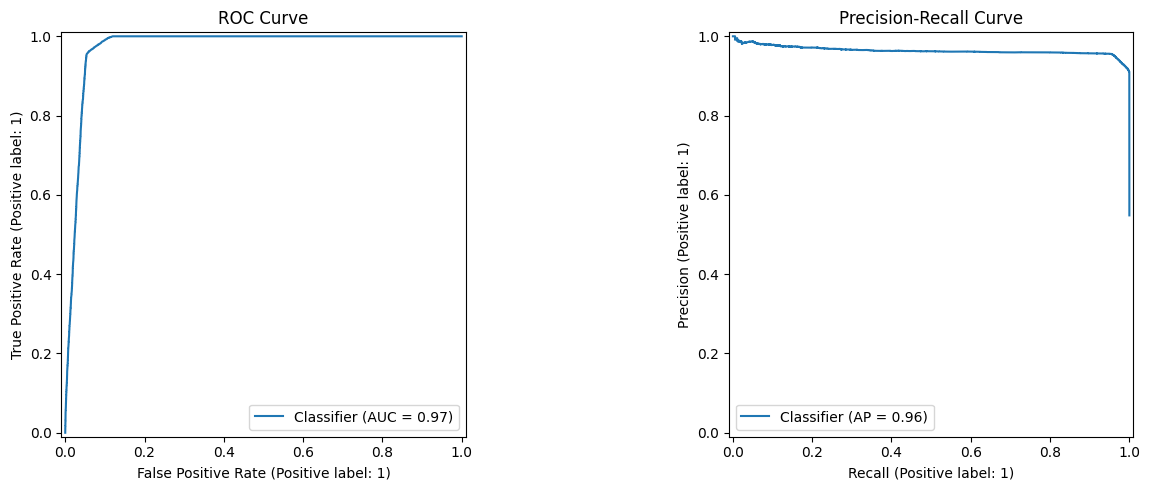

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## 10. Decision Threshold Tuning

**New in v2:** The default 0.5 threshold is rarely optimal for imbalanced problems. We pick the threshold that maximises F1 on the test set. Adjust the optimisation target (`f1`, `precision`, `recall`) based on your business priority — e.g. prefer recall if missing a late delivery is more costly than a false alarm.

In [12]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)

# F1 for each threshold
f1_scores = 2 * precision_vals[:-1] * recall_vals[:-1] / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-8
)

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1) : {best_threshold:.4f}")
print(f"Precision at threshold  : {precision_vals[best_idx]:.4f}")
print(f"Recall    at threshold  : {recall_vals[best_idx]:.4f}")
print(f"F1        at threshold  : {f1_scores[best_idx]:.4f}")

# Re-evaluate with tuned threshold
y_pred_tuned = (y_proba >= best_threshold).astype(int)
print("\nClassification Report (tuned threshold)")
print("=" * 50)
print(classification_report(y_test, y_pred_tuned))

Best threshold (max F1) : 0.4250
Precision at threshold  : 0.9425
Recall    at threshold  : 0.9715
F1        at threshold  : 0.9568

Classification Report (tuned threshold)
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     16308
           1       0.94      0.97      0.96     19796

    accuracy                           0.95     36104
   macro avg       0.95      0.95      0.95     36104
weighted avg       0.95      0.95      0.95     36104



## 11. SHAP Feature Importance

**New in v2:** `plot_importance(model)` in v1 showed f0/f1/f2 (internal indices after OHE), which is uninterpretable. SHAP uses the transformed feature names and shows actual impact on predictions.

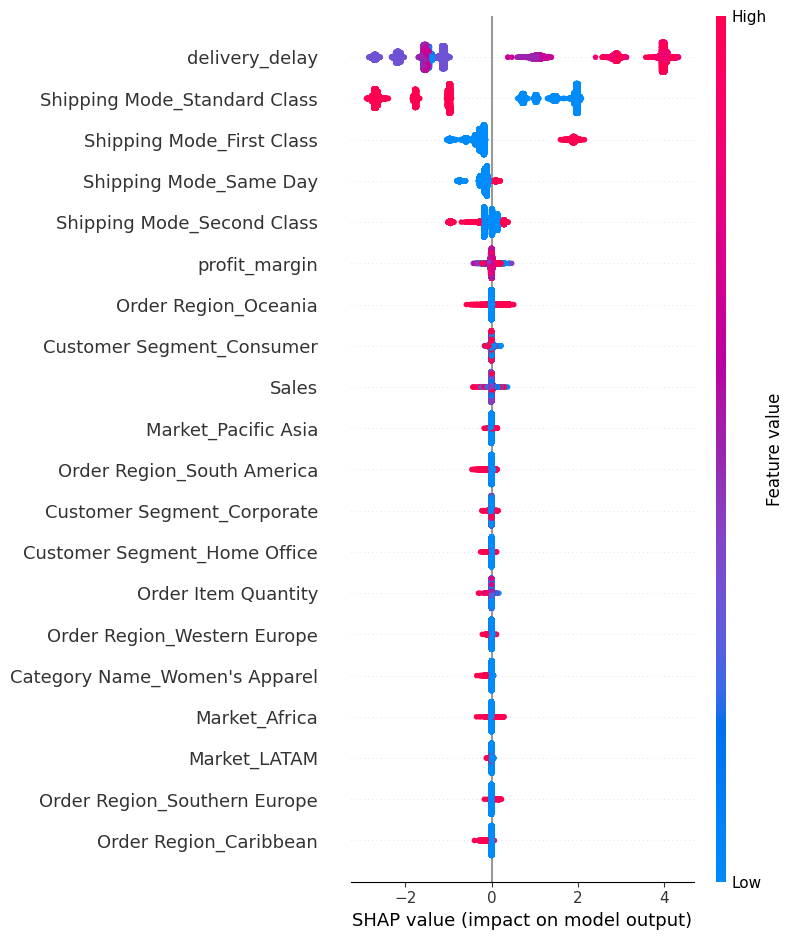

In [13]:
# Extract trained components from the pipeline
model_step        = pipeline.named_steps['model']
preprocessor_step = pipeline.named_steps['preprocessor']

# Get transformed feature names
ohe_feature_names = preprocessor_step.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(ohe_feature_names) + numerical_cols

# Transform test set
X_test_transformed = preprocessor_step.transform(X_test)

# SHAP explainer
explainer   = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot — shows feature importance with directionality
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    show=True
)

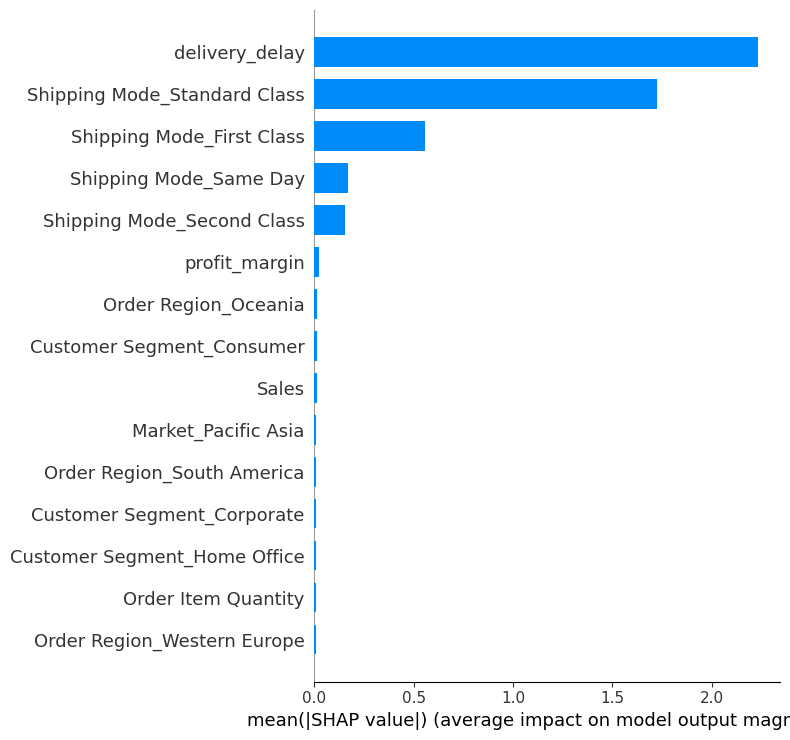

In [14]:
# Bar plot — mean absolute SHAP value per feature (top 15)
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar',
    max_display=15,
    show=True
)

## 12. Save Pipeline & Threshold

In [15]:
# Save the full pipeline
with open("pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

# Save the tuned threshold alongside — needed at inference time
with open("threshold.pkl", "wb") as f:
    pickle.dump(best_threshold, f)

print("Pipeline saved  → pipeline.pkl")
print(f"Threshold saved → threshold.pkl  ({best_threshold:.4f})")

Pipeline saved  → pipeline.pkl
Threshold saved → threshold.pkl  (0.4250)


## 13. Inference Example

How to load and use the saved model with the tuned threshold at serving time.

In [16]:
# --- Load ---
with open("pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

with open("threshold.pkl", "rb") as f:
    loaded_threshold = pickle.load(f)

# --- Predict ---
sample = X_test.iloc[:5]
proba  = loaded_pipeline.predict_proba(sample)[:, 1]
pred   = (proba >= loaded_threshold).astype(int)

results = pd.DataFrame({
    'probability'       : proba,
    'predicted_label'   : pred,
    'actual_label'      : y_test.iloc[:5].values
})
print(results)

   probability  predicted_label  actual_label
0     0.010350                0             0
1     0.008497                0             0
2     0.010380                0             0
3     0.403856                0             0
4     0.416650                0             1
